<a href="https://colab.research.google.com/github/OrastaRakhmatullayeva/ML-projects/blob/main/EDA_project_student_productivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [24]:
!pip install opendatasets

In [25]:
import opendatasets as od

In [26]:
od.download('https://www.kaggle.com/competitions/student-performance-prediction-machine-learning-challenge/data')

Skipping, found downloaded files in "./student-performance-prediction-machine-learning-challenge" (use force=True to force download)


In [27]:
df=pd.read_csv('/content/student-performance-prediction-machine-learning-challenge/train.csv')

In [28]:
df.shape     #to check the shape , how many columns and rows in dataset

(16000, 19)

In [29]:
df.head()  #to print beginning 5 rows

,id,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,5894,5895,28,Other,4.56,7.61,1.70,7.23,3.80,3.18,2,256,102,14,52.72,6,68,70.48,55.29
1,3728,3729,18,Female,7.95,8.17,4.24,5.50,4.80,3.53,9,370,115,17,87.51,1,69,57.67,78.68
2,8958,8959,19,Male,6.06,9.02,3.17,5.08,5.09,3.74,5,250,33,9,72.39,8,57,72.51,60.66
3,7671,7672,21,Female,1.40,8.06,2.35,1.03,0.13,5.23,4,55,110,0,87.47,5,34,81.93,37.51
4,5999,6000,25,Male,9.27,7.39,10.68,5.21,3.43,5.38,11,436,66,17,47.66,5,37,49.11,50.72


In [30]:
df.info()    #to know further informations

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     16000 non-null  int64  
 1   student_id             16000 non-null  int64  
 2   age                    16000 non-null  int64  
 3   gender                 16000 non-null  object 
 4   study_hours_per_day    16000 non-null  float64
 5   sleep_hours            16000 non-null  float64
 6   phone_usage_hours      16000 non-null  float64
 7   social_media_hours     16000 non-null  float64
 8   youtube_hours          16000 non-null  float64
 9   gaming_hours           16000 non-null  float64
 10  breaks_per_day         16000 non-null  int64  
 11  coffee_intake_mg       16000 non-null  int64  
 12  exercise_minutes       16000 non-null  int64  
 13  assignments_completed  16000 non-null  int64  
 14  attendance_percentage  16000 non-null  float64
 15  st

In [31]:
df.columns    #to know the name of columns

Index(['id', 'student_id', 'age', 'gender', 'study_hours_per_day',
       'sleep_hours', 'phone_usage_hours', 'social_media_hours',
       'youtube_hours', 'gaming_hours', 'breaks_per_day', 'coffee_intake_mg',
       'exercise_minutes', 'assignments_completed', 'attendance_percentage',
       'stress_level', 'focus_score', 'final_grade', 'productivity_score'],
      dtype='object')

In [32]:
df.isnull().sum().sum()    #the missing values

np.int64(0)

In [33]:
df.duplicated().sum()   #the duplicated values

np.int64(0)

In [34]:
df.describe()     #the mean,quantile and others are there to see

,id,student_id,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,10006.506875,10007.506875,23.020937,5.254446,6.515254,6.258692,3.995989,2.985526,2.976373,7.539625,249.035250,59.832125,9.492313,69.894694,5.478813,64.430375,70.377071,50.146637
std,5790.786923,5790.786923,3.753283,2.743874,2.033761,3.305756,2.311722,1.731141,1.733127,4.017236,143.732208,34.676427,5.781352,17.408698,2.867785,20.226804,17.293340,16.095733
min,1.000000,2.000000,17.000000,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,0.000000
25%,4993.750000,4994.750000,20.000000,2.890000,4.760000,3.390000,2.000000,1.480000,1.477500,4.000000,124.000000,30.000000,4.000000,54.740000,3.000000,47.000000,55.617500,38.657500
50%,10020.500000,10021.500000,23.000000,5.250000,6.520000,6.230000,3.990000,2.970000,2.950000,8.000000,248.000000,60.000000,9.000000,69.865000,5.000000,65.000000,70.545000,50.220000
75%,15029.250000,15030.250000,26.000000,7.632500,8.320000,9.100000,5.970000,4.480000,4.490000,11.000000,372.000000,90.000000,15.000000,85.020000,8.000000,82.000000,85.480000,61.840000
max,19999.000000,20000.000000,29.000000,10.000000,10.000000,12.000000,8.000000,6.000000,6.000000,14.000000,499.000000,119.000000,19.000000,100.000000,10.000000,99.000000,99.990000,100.000000


In [35]:
df.drop(columns=['id','student_id'],inplace=True)   #to drop columns of id and student id, it is unnecessary for our statistics

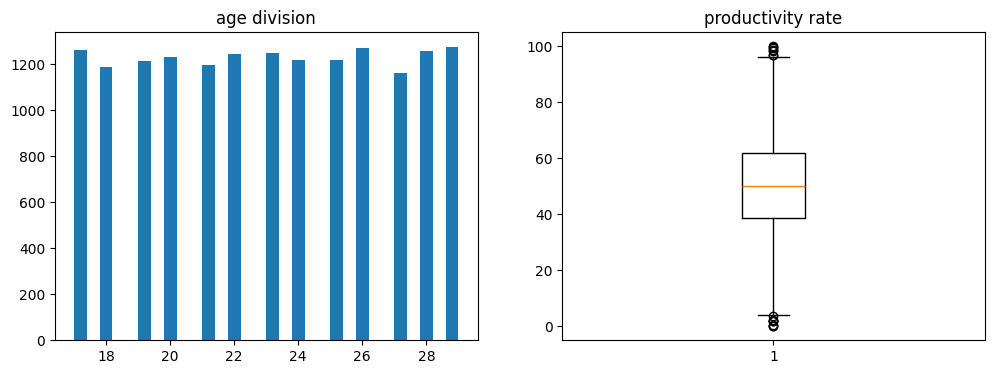

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df['age'], bins=30)
ax[0].set_title('age division')

ax[1].boxplot(df['productivity_score'])
ax[1].set_title('productivity rate')
plt.show()

In [41]:
df['gender'].value_counts()                    # sonini beradi
df['gender'].value_counts(normalize=True)   # ulushini (foizini) beradi

,proportion
gender,
Male,0.481500
Female,0.480187
Other,0.038312


In [49]:
#df.groupby('Male')['gender'].mean()        # female 0.742, male 0.189

#df.groupby('Female')['gender'].mean()     # 0.630 / 0.473 / 0.242


In [45]:
df['gender']

,gender
0,Other
1,Female
2,Male
3,Female
4,Male
...,...
15995,Female
15996,Male
15997,Other
15998,Female


In [47]:
df.corr(numeric_only=True).round(2)

,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
age,1.00,0.00,0.01,0.01,0.00,0.02,0.00,-0.00,0.01,-0.00,-0.00,-0.01,-0.00,-0.01,-0.00,-0.00
study_hours_per_day,0.00,1.00,-0.00,0.01,0.01,-0.00,-0.00,-0.01,0.01,0.01,0.01,-0.01,0.00,0.01,-0.02,0.73
sleep_hours,0.01,-0.00,1.00,0.00,-0.01,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,0.01,0.34
phone_usage_hours,0.01,0.01,0.00,1.00,0.01,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.01,0.01,-0.00,-0.01,-0.33
social_media_hours,0.00,0.01,-0.01,0.01,1.00,-0.00,0.01,-0.00,0.00,-0.00,-0.00,0.01,-0.01,0.00,-0.00,0.00
youtube_hours,0.02,-0.00,0.01,-0.00,-0.00,1.00,0.01,-0.01,0.01,0.01,0.01,0.01,0.00,0.00,0.00,0.00
gaming_hours,0.00,-0.00,0.00,-0.00,0.01,0.01,1.00,0.00,-0.01,0.00,0.00,0.01,0.01,0.00,0.00,0.00
breaks_per_day,-0.00,-0.01,0.00,-0.00,-0.00,-0.01,0.00,1.00,0.00,-0.02,0.01,0.00,-0.00,-0.00,-0.00,-0.01
coffee_intake_mg,0.01,0.01,0.00,-0.00,0.00,0.01,-0.01,0.00,1.00,0.01,0.01,0.01,-0.01,0.02,0.02,0.02
exercise_minutes,-0.00,0.01,0.00,-0.00,-0.00,0.01,0.00,-0.02,0.01,1.00,-0.01,-0.00,0.01,-0.01,-0.00,0.00


In [50]:
df.corr(numeric_only=True)['productivity_score'].sort_values(ascending=False).round(2)

,productivity_score
productivity_score,1.00
study_hours_per_day,0.73
focus_score,0.42
sleep_hours,0.34
attendance_percentage,0.17
coffee_intake_mg,0.02
assignments_completed,0.00
youtube_hours,0.00
exercise_minutes,0.00
gaming_hours,0.00


this is final one that i can speak about dataset.
because productivity rate relates to study_hours_per_day	and sleep_hours , in 0,73 and 0,34 respectively